# 05 DenseNet121 + CLAHE
 trains DenseNet121 with standard CrossEntropyLoss and CLAHE preprocessing.

Compared with the formal DenseNet121 CE baseline, only CLAHE preprocessing is added.

Purpose:
- enhance X-ray local contrast
- improve visibility of joint space and bone edges
- compare whether CLAHE improves accuracy, macro F1, MAE, QWK, and per-class metrics





In [3]:
EXPERIMENT_NAME = "densenet121_ce_clahe"

NUM_CLASSES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
MAX_EPOCHS = 30
PATIENCE = 7
MONITOR_METRIC = "qwk"

CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

print("Experiment:", EXPERIMENT_NAME)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Max epochs:", MAX_EPOCHS)
print("Patience:", PATIENCE)
print("Monitor metric:", MONITOR_METRIC)
print("CLAHE clip limit:", CLAHE_CLIP_LIMIT)
print("CLAHE tile grid size:", CLAHE_TILE_GRID_SIZE)




Experiment: densenet121_ce_clahe
Image size: 224
Batch size: 32
Learning rate: 0.0001
Max epochs: 30
Patience: 7
Monitor metric: qwk
CLAHE clip limit: 2.0
CLAHE tile grid size: (8, 8)


In [4]:
from pathlib import Path
import sys

current_path = Path.cwd()

if current_path.name in ["notebook", "notebooks"]:
    PROJECT_ROOT = current_path.parent

elif (current_path / "data").exists() and (current_path / "models").exists():
    PROJECT_ROOT = current_path

else:
    PROJECT_ROOT = current_path
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "models").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Current path:", current_path)
print("Project root:", PROJECT_ROOT)
print("models folder exists:", (PROJECT_ROOT / "models").exists())
print("densenet.py exists:", (PROJECT_ROOT / "models" / "densenet.py").exists())
print("utils folder exists:", (PROJECT_ROOT / "utils").exists())
print("train_utils.py exists:", (PROJECT_ROOT / "utils" / "train_utils.py").exists())


Current path: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\notebook
Project root: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1
models folder exists: True
densenet.py exists: True
utils folder exists: True
train_utils.py exists: True


In [5]:
import torch
import torch.nn as nn

from models.densenet import get_densenet121, count_trainable_parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = get_densenet121(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=0.3,
)

model = model.to(device)

trainable_params, total_params = count_trainable_parameters(model)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")


Device: cuda
Trainable parameters: 6,958,981
Total parameters:     6,958,981


In [6]:
# dataloader
from utils.dataset_clahe import get_dataloaders, print_dataset_info

SPLIT_ROOT = PROJECT_ROOT / "data" / "processed" / "split_images"

train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = get_dataloaders(
    split_root=SPLIT_ROOT,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    use_augmentation=True,
    clahe_clip_limit=CLAHE_CLIP_LIMIT,
    clahe_tile_grid_size=CLAHE_TILE_GRID_SIZE,
)


print_dataset_info(train_dataset, val_dataset, test_dataset)

class_names = train_dataset.classes


Dataset Information with CLAHE
Train images: 1024
Val images:   146
Test images:  294

Class to index mapping:
{'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}

Classes:
['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']


In [7]:
# loss and optimizer CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

Image batch shape: torch.Size([32, 3, 224, 224])
Image min: -2.1179039478302
Image max: 2.640000104904175


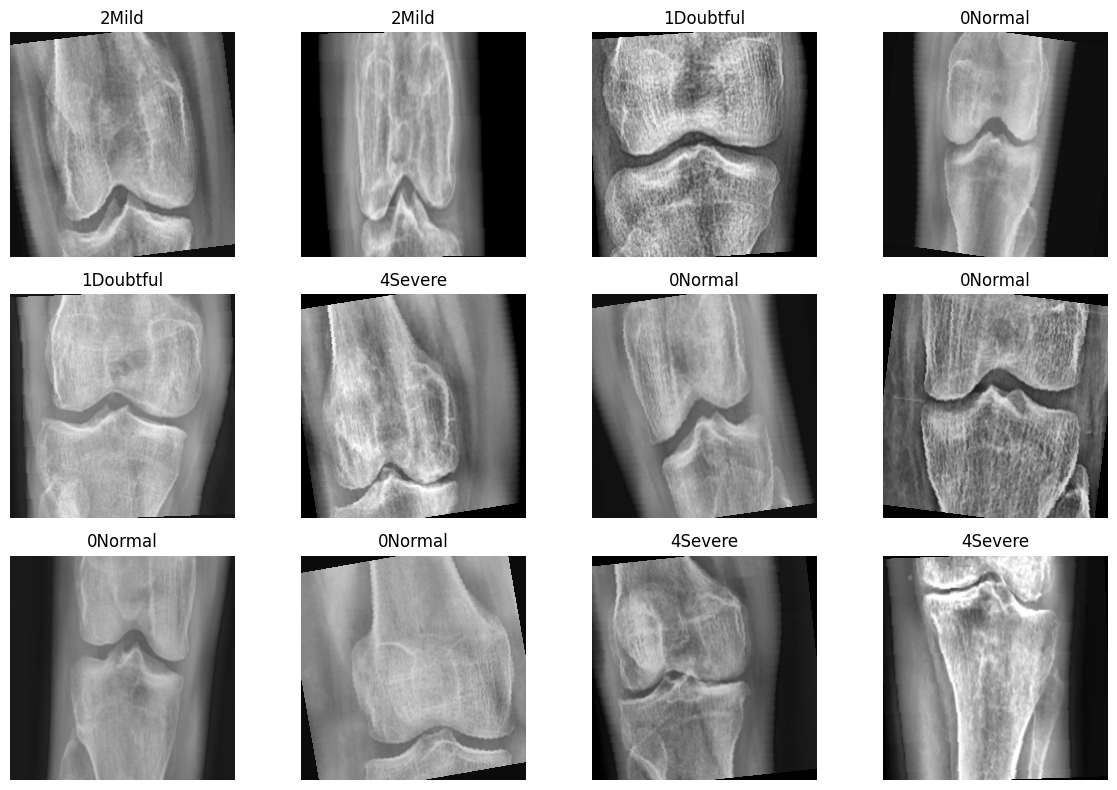

In [8]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Image min:", images.min().item())
print("Image max:", images.max().item())

import torch
import matplotlib.pyplot as plt

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize(img_tensor):
    img = img_tensor.cpu() * IMAGENET_STD + IMAGENET_MEAN
    img = torch.clamp(img, 0, 1)
    return img

plt.figure(figsize=(12, 8))

for i in range(12):
    img = denormalize(images[i])
    label = labels[i].item()

    plt.subplot(3, 4, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()




## create densenet

In [9]:
from utils.train_utils import train_model

SAVE_PATH = PROJECT_ROOT / "outputs" / "models" / f"{EXPERIMENT_NAME}.pth"

model, history_df = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=MAX_EPOCHS,
    save_path=SAVE_PATH,
    monitor_metric=MONITOR_METRIC,
    patience=PATIENCE,
    min_delta=1e-4,
)





Epoch 1/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 1.3484 | Train Acc: 0.4307 | Train Macro F1: 0.3533 | Train QWK: 0.3797
Val Loss:   1.1278 | Val Acc:   0.5274 | Val Macro F1: 0.4423 | Val QWK:   0.6124 | Val MAE:   0.7466
New best model found at epoch 1.
Best val qwk: 0.6124
Saved best model to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\densenet121_ce_clahe.pth

Epoch 2/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0501 | Train Acc: 0.9844 | Train Macro F1: 0.9836 | Train QWK: 0.9900
Val Loss:   0.5908 | Val Acc:   0.8562 | Val Macro F1: 0.8476 | Val QWK:   0.8980 | Val MAE:   0.2123
No improvement in val qwk. Patience: 5/7

Epoch 30/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0460 | Train Acc: 0.9834 | Train Macro F1: 0.9834 | Train QWK: 0.9880
Val Loss:   0.5793 | Val Acc:   0.8562 | Val Macro F1: 0.8387 | Val QWK:   0.8947 | Val MAE:   0.2192
No improvement in val qwk. Patience: 6/7


In [10]:
history_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

history_df.tail()

,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
25,26,0.059773,0.743507,24,1,0.981445,0.981441,0.981471,0.028320,0.986714,...,0.823617,0.827715,0.239726,0.888889,25,19,6,0.171233,0.130137,0.041096
26,27,0.054554,0.599122,24,2,0.981445,0.981194,0.981472,0.024414,0.990748,...,0.833459,0.839211,0.239726,0.882387,23,16,7,0.157534,0.109589,0.047945
27,28,0.054854,0.616035,24,3,0.979492,0.977255,0.979511,0.030273,0.987229,...,0.812119,0.832970,0.226027,0.897659,23,16,7,0.157534,0.109589,0.047945
28,29,0.050134,0.590810,24,4,0.984375,0.983608,0.984368,0.023438,0.989997,...,0.847584,0.854138,0.212329,0.898042,21,15,6,0.143836,0.102740,0.041096
29,30,0.045986,0.579337,24,5,0.983398,0.983446,0.983447,0.025391,0.987980,...,0.838718,0.850781,0.219178,0.894656,21,14,7,0.143836,0.095890,0.047945


## best epoch 

In [12]:
best_idx = history_df["val_qwk"].idxmax()
best_row = history_df.loc[best_idx]

print("Best epoch based on validation QWK:")
print(best_row[[
    "epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "val_weighted_f1",
    "val_mae",
    "val_qwk",
    "val_adjacent_errors",
    "val_distant_errors",
]])



Best epoch based on validation QWK:
epoch                  24.000000
val_loss                0.533847
val_accuracy            0.835616
val_macro_f1            0.808214
val_weighted_f1         0.827055
val_mae                 0.205479
val_qwk                 0.920238
val_adjacent_errors    20.000000
val_distant_errors      4.000000
Name: 23, dtype: float64


## train model

In [13]:
SAVE_PATH = PROJECT_ROOT / "outputs" / "models" / "densenet121_ce_clahe.pth"

model, history_df = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=10,
    save_path=SAVE_PATH,
    monitor_metric="qwk",
)



Epoch 1/10
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0852 | Train Acc: 0.9717 | Train Macro F1: 0.9713 | Train QWK: 0.9855
Val Loss:   0.6266 | Val Acc:   0.8562 | Val Macro F1: 0.8431 | Val QWK:   0.8990 | Val MAE:   0.2192
New best model found at epoch 1.
Best val qwk: 0.8990
Saved best model to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\densenet121_ce_clahe.pth

Epoch 2/10
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0840 | Train Acc: 0.9727 | Train Macro F1: 0.9718 | Train QWK: 0.9877
Val Loss:   0.5816 | Val Acc:   0.8014 | Val Macro F1: 0.7925 | Val QWK:   0.9020 | Val MAE:   0.2466
No improvement in val qwk. Patience: 1/7

Epoch 10/10
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0617 | Train Acc: 0.9795 | Train Macro F1: 0.9787 | Train QWK: 0.9882
Val Loss:   0.6260 | Val Acc:   0.8219 | Val Macro F1: 0.8045 | Val QWK:   0.9110 | Val MAE:   0.2329
New best model found at epoch 10.
Best val qwk: 0.9110
Saved best model to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\densenet121_ce_clahe.pth


save history

In [14]:
history_path = PROJECT_ROOT / "outputs" / "results" / "densenet121_ce_clahe_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

history_df


,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
0,1,0.085169,0.626607,0,0,0.971680,0.971283,0.971725,0.037109,0.985461,...,0.843104,0.849727,0.219178,0.899027,21,13,8,0.143836,0.089041,0.054795
1,2,0.069026,0.583462,1,0,0.981445,0.980138,0.981493,0.030273,0.985733,...,0.773497,0.791820,0.280822,0.877379,29,21,8,0.198630,0.143836,0.054795
2,3,0.063672,0.634584,1,1,0.976562,0.974262,0.976531,0.040039,0.979736,...,0.836397,0.852255,0.205479,0.905146,20,13,7,0.136986,0.089041,0.047945
3,4,0.061369,0.526924,3,0,0.979492,0.976366,0.979549,0.031250,0.985453,...,0.817032,0.832712,0.226027,0.900211,24,19,5,0.164384,0.130137,0.034247
4,5,0.079434,0.540804,3,1,0.970703,0.968438,0.970722,0.039062,0.984013,...,0.789153,0.807031,0.260274,0.885273,27,20,7,0.184932,0.136986,0.047945
5,6,0.081513,0.636552,3,2,0.968750,0.969463,0.968801,0.043945,0.981700,...,0.791189,0.805449,0.260274,0.887207,27,20,7,0.184932,0.136986,0.047945
6,7,0.070369,0.647952,3,3,0.972656,0.973889,0.972655,0.039062,0.982495,...,0.795545,0.807096,0.260274,0.891762,28,21,7,0.191781,0.143836,0.047945
7,8,0.074898,0.593508,3,4,0.973633,0.972894,0.973620,0.033203,0.987447,...,0.807280,0.824230,0.226027,0.906303,25,20,5,0.171233,0.136986,0.034247
8,9,0.084007,0.581570,8,0,0.972656,0.971758,0.972787,0.034180,0.987687,...,0.792458,0.805041,0.246575,0.902018,29,24,5,0.198630,0.164384,0.034247
9,10,0.061730,0.626016,8,1,0.979492,0.978674,0.979534,0.028320,0.988194,...,0.804495,0.814301,0.232877,0.911008,26,20,6,0.178082,0.136986,0.041096


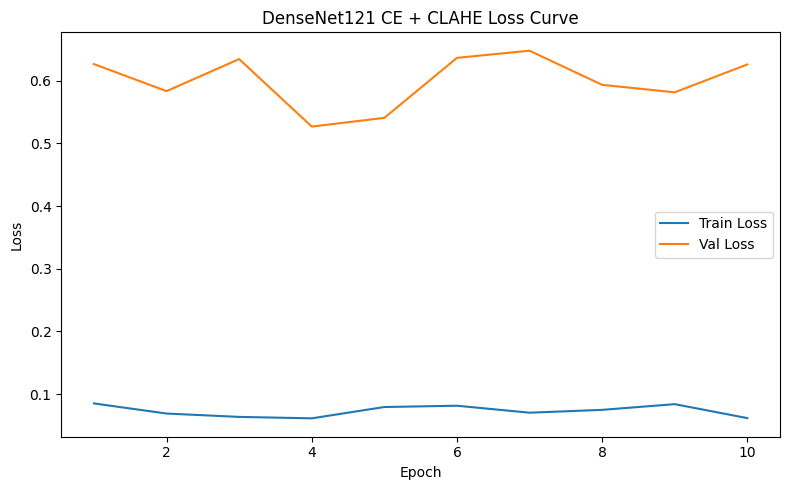

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_ce_clahe_loss.png


In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 CE + CLAHE Loss Curve")
plt.legend()
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / "densenet121_ce_clahe_loss.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


In [16]:
from utils.train_utils import train_model, evaluate_model
from utils.metrics import print_metrics
# train set
val_loss, val_metrics, val_true, val_pred = evaluate_model(
    model=model,
    data_loader=val_loader,
    criterion=criterion,
    device=device,
)

print_metrics(val_metrics, title="Validation Metrics")


Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Validation Metrics
accuracy: 0.8219
macro_f1: 0.8045
weighted_f1: 0.8143
mae: 0.2329
qwk: 0.9110
total_errors: 26
adjacent_errors: 20
distant_errors: 6
total_error_rate: 0.1781
adjacent_error_rate: 0.1370
distant_error_rate: 0.0411


In [18]:
from utils.metrics import get_classification_report
import pandas as pd


# test set
test_loss, test_metrics, test_true, test_pred = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

print_metrics(test_metrics, title="CLAHE Test Metrics")

test_metrics_df = pd.DataFrame([{
    "experiment": EXPERIMENT_NAME,
    "loss": test_loss,
    "clahe_clip_limit": CLAHE_CLIP_LIMIT,
    "clahe_tile_grid_size": str(CLAHE_TILE_GRID_SIZE),
    **test_metrics
}])

test_metrics_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_test_metrics.csv"
test_metrics_path.parent.mkdir(parents=True, exist_ok=True)

test_metrics_df.to_csv(test_metrics_path, index=False)

test_metrics_df


Validation:   0%|          | 0/10 [00:00<?, ?it/s]

CLAHE Test Metrics
accuracy: 0.7891
macro_f1: 0.7859
weighted_f1: 0.7875
mae: 0.2959
qwk: 0.8682
total_errors: 62
adjacent_errors: 45
distant_errors: 17
total_error_rate: 0.2109
adjacent_error_rate: 0.1531
distant_error_rate: 0.0578


,experiment,loss,clahe_clip_limit,clahe_tile_grid_size,accuracy,macro_f1,weighted_f1,mae,qwk,total_errors,adjacent_errors,distant_errors,total_error_rate,adjacent_error_rate,distant_error_rate
0,densenet121_ce_clahe,0.773455,2.0,"(8, 8)",0.789116,0.785904,0.787543,0.295918,0.868165,62,45,17,0.210884,0.153061,0.057823


In [19]:
#classification report 
report = get_classification_report(
    y_true=test_true,
    y_pred=test_pred,
    class_names=class_names,
)

print(report)

              precision    recall  f1-score   support

     0Normal       0.81      0.87      0.84        91
   1Doubtful       0.75      0.73      0.74        88
       2Mild       0.71      0.63      0.67        38
   3Moderate       0.81      0.86      0.83        35
     4Severe       0.88      0.83      0.85        42

    accuracy                           0.79       294
   macro avg       0.79      0.78      0.79       294
weighted avg       0.79      0.79      0.79       294



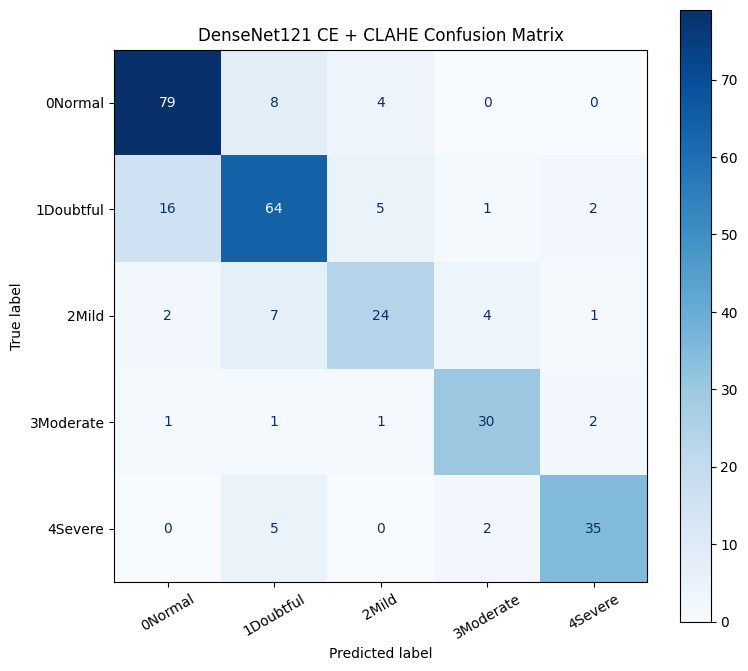

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_ce_clahe_confusion_matrix.png


In [20]:
# Confusion matrix
from utils.metrics import get_confusion_matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = get_confusion_matrix(test_true, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.title("DenseNet121 CE + CLAHE Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / "densenet121_ce_clahe_confusion_matrix.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)
